This is the baseline model for the project. 
It is a linear SVM. The SVM will be trained on a feature-user matrix corresponding to the Term Frequency – Inverse Document Frequency (TF-IDF)-weighted words contained in each user’s tweets. And I will compute the TF-IDF for all tweets, not just those from the same users.
In this method, each word (unigram) in the posts is treated separately and weighted according to its  importance in predicting the political party associated with the post. For the main model, I have decided to include punctuation marks, mentions of users and capital letters, as I believe these can be useful for distinguishing between Democrats and Republicans. 
I will tried to do the same for the baseline model but got better results by removing capital letters, punctuation and one-letter words. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
#Load and split the Data

df = pd.read_parquet('congress_tweets_dataset_cleaned.parquet')


# We use 75% for training and 25% for testing and take the most recents tweets for testing

#Ensure the time column is in datetime format
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').reset_index(drop=True)

train_ratio = 0.75

# Split each party's data chronologically
# This ensures that for BOTH 'D' and 'R', the last 25% are used for testing (so we keep the same proportion of republicain and democrat tweets in both sets)
train_list = []
test_list = []

for label in ['D', 'R']:
    party_df = df[df['label'] == label]
    
    # Calculate the split point (index)
    split_idx = int(len(party_df) * train_ratio)
    
    # Split: first 80% to train, last 20% to test
    train_list.append(party_df.iloc[:split_idx])
    test_list.append(party_df.iloc[split_idx:])

# Combine the splits back into final DataFrames
df_train = pd.concat(train_list)
df_test = pd.concat(test_list)

# Shuffle the training and test data 
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

# We split the features and the labels 
X_train, y_train = df_train['text'], df_train['label']
X_test, y_test = df_test['text'], df_test['label']

# Verification
print(f"Training set size: {len(X_train)} (Ending at {df_train['time'].max()})")
print(f"Test set size: {len(X_test)} (Starting from {df_test['time'].min()})")
print(f"\nLabel distribution in Test set:\n{y_test.value_counts(normalize=True)}")

Training set size: 3264206 (Ending at 2022-01-28 16:55:48+00:00)
Test set size: 1088069 (Starting from 2021-10-20 16:40:08+00:00)

Label distribution in Test set:
label
D    0.589825
R    0.410175
Name: proportion, dtype: float64


In [ ]:
# TF-IDF Feature Extraction

# lowercase=False keeps capital letters
# token_pattern=r'\S+' splits tokens by whitespace, keeping punctuation attached to words

vectorizer = TfidfVectorizer(
    lowercase=True, 
    max_features=100000 # Limit to top 10k words to save memory/time
)

#I tried :
#lowercase = False, and token_pattern=r'\S+' to keep capital letters and punctuation
#lowercase = True and token_pattern=r'\S+' to remove capital letters but keep punctuation
#lowercase = True and default token_pattern to remove capital letters and punctuation and keep only words of more than two letters

#The last one gave the best results, so I kept it (and changed my initial idea of keeping capital letters and punctuation because it was not helping)
#I also tried to put max_features = 5000, 40000, 100000 and kept the best one (100000)


X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [4]:
# Train the Linear SVM Model

svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [5]:
y_train_pred = svm_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.8876


I tested several parameters for the models (with the train data, not the test ones) : 

Train accuracy for different parameters : 

with max_features = 10000 :
- keeping capital letters and punctuation : 0.8057

- keeping punctuation : 0.8103

- removing punctuation, capital letters and keeping only word of more than two letters : 0.8315

I kept the last model and changed max_features : 
- 5000 : 0.7982
- 20000 : 0.8554
- 40000 : 0.8723
- 60000 : 0.8798
- 100000 : 0.8876

Last test : keeping capital letters and punctuation and max_features = 100000, just to make sure than keeping capital letters and punctuation dosn't help when more features are kept : 0.8846


Accuracy: 0.8425

Classification Report:
              precision    recall  f1-score   support

           D       0.88      0.85      0.86    641770
           R       0.79      0.83      0.81    446299

    accuracy                           0.84   1088069
   macro avg       0.84      0.84      0.84   1088069
weighted avg       0.84      0.84      0.84   1088069



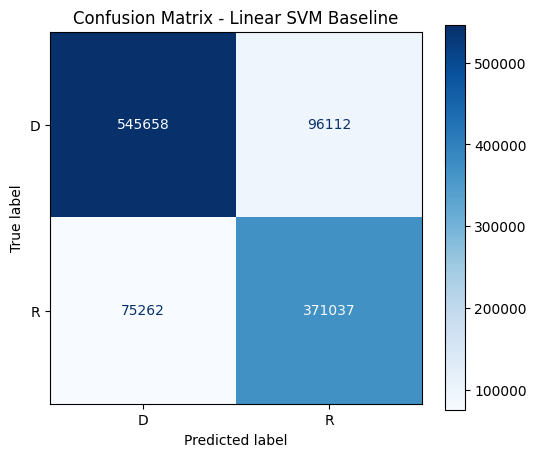

In [6]:
#evaluation of the model on test data

y_pred = svm_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Linear SVM Baseline')
plt.show()

In [7]:
# Qualitative Results (Feature Analysis)

# Get the feature names and the model coefficients
feature_names = vectorizer.get_feature_names_out()
coefficients = svm_model.coef_[0]

# Create a DataFrame of words and their SVM weights
feature_df = pd.DataFrame({'word': feature_names, 'weight': coefficients})
class_0, class_1 = svm_model.classes_

print(f"\nTop 10 words most indicative of {class_0}:")
top_class_0 = feature_df.sort_values(by='weight', ascending=True).head(10)
print(top_class_0)

print(f"\nTop 10 words most indicative of {class_1}:")
top_class_1 = feature_df.sort_values(by='weight', ascending=False).head(10)
print(top_class_1)


Top 10 words most indicative of D:
                     word    weight
38706          goptaxscam -7.717122
18127          cfinst_org -7.325146
73953           redtoblue -6.947679
91388       trumpshutdown -6.639624
51184         lacyclaymo1 -6.411384
7954   americanrescueplan -6.384195
55133     marchantfortx24 -5.755492
10889                az01 -5.609631
40339          handsoffdc -5.291489
47258             jecdems -5.118847

Top 10 words most indicative of R:
                  word    weight
79563  schumershutdown  6.974457
7130      alexberenson  6.929682
16418     camillegallo  6.884365
13822        bobsalera  6.874146
16979        carlyatch  6.771249
89602      timburchett  6.716096
54316        m_mcadams  6.470391
97059    westerncaucus  6.354182
52865    lilagracerose  6.352018
64291             ny21  6.219649


In [8]:
# Show a few misclassified examples 
test_results = pd.DataFrame({'text': X_test, 'true_label': y_test, 'predicted': y_pred})
misclassified = test_results[test_results['true_label'] != test_results['predicted']]

print("\nSample of misclassified tweets (Interesting to analyze why it failed):")
pd.set_option('display.max_colwidth', None) #to be sure we can see the full text of the tweets
print(misclassified.sample(min(3, len(misclassified)))[['text', 'true_label', 'predicted']])


Sample of misclassified tweets (Interesting to analyze why it failed):
                                                                                                                                                                                                                    text  \
925221  If Members of Congress want to fly first-class, their constituents shouldn’t be stuck with the bill. Proud to lead this commonsense effort to save taxpayer dollars and rein in wasteful spending in Washington.   
508934                                                                                                                                                                              @YiAndyChen Thanks for helping Andy!   
158951                                                                                                                                                                                             @saxocrat thank you!!   

       true_label predicted  
925221          D

In [10]:
# Learning Curve 

train_sizes, train_scores, test_scores = learning_curve(
    svm_model, X_train_tfidf, y_train, cv=5, 
    n_jobs=2, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
plt.title("Learning Curve (Linear SVM)")
plt.xlabel("Training examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid()
plt.show()

KeyboardInterrupt: 